# Credit Card Fraud Detection

## Objective
Identify **fraudulent credit card transactions** using machine learning.

## Dataset Overview
The dataset contains anonymized credit card transactions labeled as fraud or not.

- `Time`, `Amount`, and anonymized features `V1` to `V28`
- `Class`: 1 for fraud, 0 for non-fraud

## Workflow
1. Load and explore the dataset
2. Handle class imbalance
3. Feature scaling and model training
4. Evaluate performance

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



*** *pandas: used for data manupulation and analysis, especially working with Data frames(excel data) *numpy: used for numerical operations especially with arrays. *seaborn: A high level data visuallization library built on top of matplotlib, often used for statistical plots. *sklearn.model_selection.train_test_split: A function to split your data into training and testing sets *sklearn.preprocessing.standandardscaler: A standard for standardadizing numerical features *sklearn.linear_model.logisticregression: The classification model we'll be using *sklearn.metrics.classification_report,sklearn.metrics.confusion_matrix: Functions to evaluate the performance of our model***

loading the data set

In [2]:
# Load the dataset
df = pd.read_csv("creditcard.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


***output of head : the first few rows of the data.***

****** *you have 284,807 entries(rows) in your data set. *there are 31 columns (features), including 'Time', 'v1' through 'v28', 'Amount', and 'class'. *all columns has 284,807 non-null vaues, which means there are no missing data points in this data set. *most of the features('v1' to 'v28','Time','Amount') are of the float64 data type (floating point numbers), and the 'class' column is of int64(integer)***

***EDA : explanatory data analysis-count of Fruad vs non-fruad count the number of fraud (1) and non-fruad(0)***

## Exploratory Data Analysis

Distribution of fraudulent vs Non-Fraudulent Transactions:
Class
0    284315
1       492
Name: count, dtype: int64


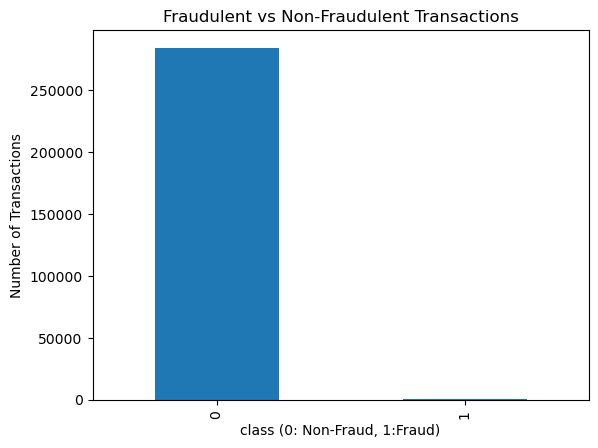

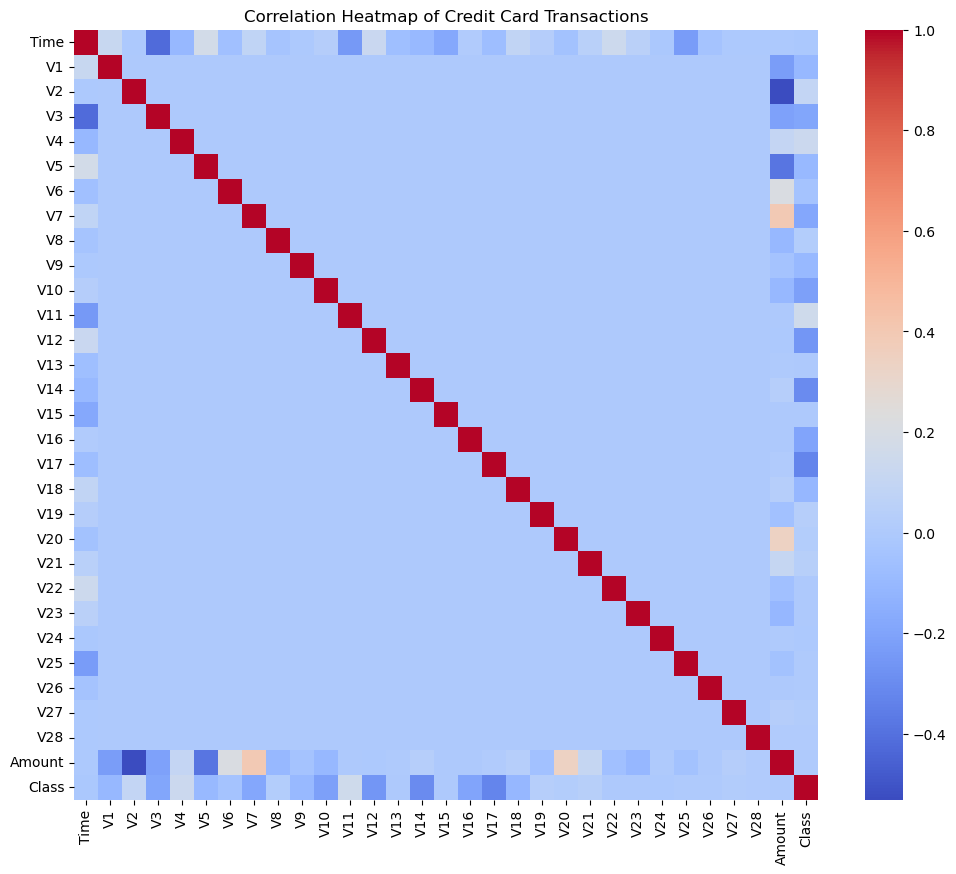

In [3]:
# Count of fraud vs non-fraud
#count the number of fraud and non-fraudulant transactions
fraud_counts = df['Class'].value_counts()
print("Distribution of fraudulent vs Non-Fraudulent Transactions:")
print(fraud_counts)

#You can also visualize this as a bar chart
fraud_counts.plot(kind='bar',title='Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('class (0: Non-Fraud, 1:Fraud)')
plt.ylabel('Number of Transactions')
plt.show()
# Correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap of the correlation matrix
fig = plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Credit Card Transactions')
plt.show()

***it shows the output of counts and barchart total non-fraudulent transactions(class 0) = 284,315 fraudulent transactions(class 1)= 492 it shows the significant imbalance the number of non-fraudulent transactions is vastly higher than number of fraudulent imbalance.this imbalance is common challange in fraudulent detection,we need to be mindful of it when we train our model, as it could lead on a model that is very good at predicting non-fraudulent cases but poor at identifying fraud.

eda- corelation heatmap a corelation heatmap helps us to visualize the relationships between different features in the data set. it can show us which features are positively or negatively corelated with each and other and, importantly, with the target variable('class') u can generate the corelation heat map using seaborn library***


* Reddish colors: Mean that when that feature's value is higher, fraud is more likely.
   * Bluish colors: Mean that when that feature's value is higher, fraud is less likely.
   * Light colors (close to white): Mean that the feature doesn't really tell you anything about whether a transaction is fraudulent or not.
 * Look at the last row (or column): This is the most important part! It shows how each feature relates to the 'Class' (fraud or not).
   * Are there any features with dark red in this row/column? If so, those features might be strong indicators of fraud when their values are high.
   * Are there any features with dark blue? If so, those features might indicate a lower chance of fraud when their values are high.
   * Most of the features in your heatmap have light colors in the last row/column. This means that, individually, they don't give us a strong signal about fraud. This isn't surprising for the 'V' features, which are transformed.
What did we see in your heatmap?
 * 'Amount' was a very, very light red. This means that slightly larger transactions might be a tiny bit more likely to be fraudulent, but it's not a strong indicator.
 * 'Time' was a very, very light blue. This means that fraudulent transactions might be a tiny bit less likely at certain times, but again, it's not a strong signal.
 * The 'V' features were mostly light colors. This means that, on their own, they don't strongly predict fraud. But, they might be important in combination with each other.
In summary:
Your heatmap doesn't show any single feature that's a smoking gun for fraud. But, it's a starting point. It tells us that we'll likely need to use the combination of features to build a good fraud detection model.

## Data Preprocessing


***feature scaling is important for algorithms like Logistic Regression. We'll use StandardScaler to scale these two features from your original DataFrame (df)***

In [ ]:
# Feature scaling for 'Amount' and 'Time'
from sklearn.preprocessing import StandardScaler

#initialize the standard scaler
scaler = StandardScaler()

#fit and transform the 'amount' column 
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))

#fit and transform time column
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

#drop the original 'amount' and 'time' columns 
df.drop(['Amount','Time'],axis=1,inplace=True)

#display the first few rows with the scaled features
print(df.head())
# Drop original columns
#reararnge the columns
#***notebook does'nt specify the column ,often it used to have the target variable(class) at the end of the data frame,lets rearrange the columns to achieve this.***

# Rearranging columns
#get all column names except 'class'
cols = [col for col in df.columns if col != 'Class']

#create a new column order by adding 'class' at the end
new_cols = cols + ['Class']

#reindex the data frame with the new column order
df = df[new_cols]

#display the first few rows with the rearranged columns
print(df.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  scaled_amount  scaled_time  

*Gets all columns except 'class': it creates a list cols containing all columns names that are not 'class' *creates the new order: it creates a new list new_cols by appending the 'Class' to the end of the cols list *reindexes the dataframe: it uses thois new list of column names to reorder the columns in the data frame df. *displays the head: it prints the first few rows of the data frame to show the new column order with 'Class' at the end. the output of head confirms that the 'Class' is now at the very end of your DataFrame. This compemsates the Datapreprocessing steps outlined in your notebook

feature scaling for amount and time the output of df.head() shows you have scaled amount and time columns in your data frame, and the original amount and time column has sucessfully dropped .the values in scaled columns are now centered around zero and have a standard deviation of one

## Model Training

In [18]:
# Define features and target
from sklearn.model_selection import train_test_split

#seperate features (x) and target (y)
x = df.drop('Class', axis = 1)
y = df['Class']

#split the data into training and testing sets with stratification
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

#print the shapes of the training and testing sets
print("shape of x_train:",x_train.shape)
print("shape of x_test:",x_test.shape)
print("shape of y_train:",y_train.shape)
print("shape of y_test:",y_test.shape)

#check the class distribution in the training and testing seta
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nclass distribution in y_test:")
print(y_test.value_counts(normalize=True))
# Train-test split with stratification

from imblearn.over_sampling import SMOTE

#initializing the SMOTE
smote = SMOTE(random_state=42)

#apply SMOTE to the training data
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

#check the class distribution in the re_sampled training data
print("Class distribution in resampled y_train:")
print(pd.Series(y_train_resampled).value_counts())

print("\n Shape of x_train_reasampled:",x_train_resampled.shape)
print("Shape of y_train_resampled:",y_train_resampled.shape)

# model training -train this logestic regression model

# Logistic Regression
from sklearn.linear_model import LogisticRegression

#initialize the LogisticRegression model
logistic_model = LogisticRegression(random_state=42)

#you can adjust hyparameters here if needed


#train the model on the resampled training data
logistic_model.fit(x_train_resampled,y_train_resampled)

print("logistic regression model trained!")
#model has learned from the balanced training data.next step to make predictions from the unseen test data (x_test) to evaluate its performance***

#now we will use the trained logistic moel to make predictions on the unseen test data(x_test) ***
# Predictions
#make predictions on the test data 
y_pred = logistic_model.predict(x_test)

#print the first few predictions
print("First few predictions on the test set:")
print(y_pred[:10])

#print the actual class labels for the first few test samples
print("\nactual class labels for the first few test samples:")
print(y_test[:10].values)


shape of x_train: (199364, 30)
shape of x_test: (85443, 30)
shape of y_train: (199364,)
shape of y_test: (85443,)

Class distribution in y_train:
Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64

class distribution in y_test:
Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64
Class distribution in resampled y_train:
Class
0    199020
1    199020
Name: count, dtype: int64

 Shape of x_train_reasampled: (398040, 30)
Shape of y_train_resampled: (398040,)
logistic regression model trained!
First few predictions on the test set:
[0 0 0 0 0 0 0 0 0 0]

actual class labels for the first few test samples:
[0 0 0 0 0 0 0 0 0 0]


Makes predictions: The predict() method of our trained logistic_model takes the features of the test set (X_test) as input and outputs the predicted class labels (0 or 1) for each transaction. These predictions are stored in the y_pred variable.
Prints first few predictions: This shows the first 10 predictions made by the model.
Prints actual labels: This shows the actual class labels for the corresponding first 10 transactions in the test set (y_test). Comparing these with the predictions will give us an initial sense of how well the model is performing.

In [8]:
from imblearn.over_sampling import SMOTE

#initializing the SMOTE
smote = SMOTE(random_state=42)

#apply SMOTE to the training data
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

#check the class distribution in the re_sampled training data
print("Class distribution in resampled y_train:")
print(pd.Series(y_train_resampled).value_counts())

print("\n Shape of x_train_reasampled:",x_train_resampled.shape)
print("Shape of y_train_resampled:",y_train_resampled.shape)

Class distribution in resampled y_train:
Class
0    199020
1    199020
Name: count, dtype: int64

 Shape of x_train_reasampled: (398040, 30)
Shape of y_train_resampled: (398040,)


In [11]:
#evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#generate the classification report
cr = classification_report(y_test, y_pred)
print("\nclassification report:")
print(cr)

#calculate the accuracy score 
accuracy = accuracy_score(y_test, y_pred)
print("\naccuracy score:",accuracy)


classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443


accuracy score: 0.977329915850333


import evaluation metrics:we import the necessary functions from sklearn.metrics generates confusion matrics: confusion_matrix(y_test, y_pred)compares the actual test labels y_test with the predicted labels y_pred and creates a confusion matrix. the confusion matrix helps us visualize the number of true positives, true negitives, false positives, false negatives *** prints confusion matrix: it displays the confusion matrix. [[True Negatives, False Positives], [False Negatives, True Positives]] *** Generates classification report: classification_report(y_test, y_pred) provides a comprehensive summary of the model's performance, including precision, recall, F1-score, and support for each class (0 and 1). *** Prints classification report: It displays the classification report.*** *** Calculates accuracy score: accuracy_score(y_test, y_pred) calculates the overall accuracy of the model, which is the proportion of correctly classified instances out of the total number of instances.*** *** Prints accuracy score: It displays the accuracy.*** *** now we can interpret them to understand how well our Logistic Regression model is performing at detecting credit card fraud on the unseen test data.***

**Classification Report:

Class 0 (Non-Fraud):

Precision: 1.00. This means that when the model predicts a transaction is non-fraudulent, it is correct 100% of the time in the test set.
Recall: 0.98. This means that the model correctly identified 98% of all the actual non-fraudulent transactions in the test set.
F1-score: 0.99. This is the harmonic mean of precision and recall, providing a balanced measure. A high F1-score indicates good performance for this class.
Support: 85295. This is the number of actual non-fraudulent transactions in the test set.
Class 1 (Fraud):

Precision: 0.06. This is a very low precision. It means that when the model predicts a transaction as fraudulent, it is only correct 6% of the time. The other 94% of the transactions it flagged as fraud were actually non-fraudulent (false positives).
Recall: 0.88. This is a relatively high recall. It means that the model correctly identified 88% of all the actual fraudulent transactions in the test set.
F1-score: 0.12. This is a very low F1-score, indicating poor overall performance for detecting fraudulent transactions, heavily influenced by the low precision.
Support: 148. This is the number of actual fraudulent transactions in the test set.
Accuracy: 0.977. The overall accuracy of the model is about 97.7%. This seems high, but it's important to remember the significant class imbalance. The model is very good at predicting the majority class (non-fraud) but struggles with the minority class (fraud). Accuracy can be misleading in imbalanced datasets.

Macro Avg: The unweighted average of precision, recall, and F1-score across both classes.

Weighted Avg: The weighted average of precision, recall, and F1-score, weighted by the support (number of samples) for each class. This is a more useful metric in imbalanced datasets. Confusion Matrix (We can infer from the classification report):

True Negatives (TN): High (contributes to the high recall of class 0).

False Positives (FP): High (contributes to the low precision of class 1).

False Negatives (FN): Low (contributes to the high recall of class 1).

True Positives (TP): Relatively high (88% of actual fraud was caught, but this is a small absolute number due to the low support). Interpretation: This Logistic Regression model, after SMOTE on the training data, is very good at identifying non-fraudulent transactions (high precision and recall for class 0). However, it is performing poorly at correctly identifying fraudulent transactions (very low precision for class 1), even though it manages to capture a large proportion of the actual fraud cases (high recall for class 1). The low precision for fraud means that the model is generating a lot of false alarms, flagging many legitimate transactions as fraudulent.cause,

SMOTE and Logistic Regression: While SMOTE helps balance the training data, Logistic Regression might still be struggling to generalize well to the unseen, imbalanced test data. The synthetic data created by SMOTE might not perfectly represent the characteristics of real fraudulent transactions in the test set.

Choice of Model: Logistic Regression might not be the most suitable algorithm for this type of imbalanced classification problem, even with oversampling.

Feature Engineering: The anonymized 'V' features might not be directly informative enough for the model to effectively distinguish between fraud and non-fraud.

#trying different methods like random forest or XGBoost. these algorithms often perform better on imbalanced data sets and can capture more complex non-linear relationships in data



## Evaluation

In [19]:
# Confusion matrix and classification report

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Initialize the Random Forest model
random_forest = RandomForestClassifier(random_state=42)

# Train the model on the resampled training data
random_forest.fit(x_train_resampled, y_train_resampled)

# Make predictions on the test data
y_pred_rf = random_forest.predict(x_test)

# Evaluate the Random Forest model
print("Random Forest - Confusion Matrix:")
print(confusion_matrix(np.array(y_test), np.array(y_pred_rf)))
print("\nRandom Forest - Classification Report:")
print(classification_report(np.array(y_test), np.array(y_pred_rf)))
print("\nRandom Forest - Accuracy Score:", accuracy_score(np.array(y_test), np.array(y_pred_rf)))



Random Forest - Confusion Matrix:
[[85275    20]
 [   33   115]]

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.78      0.81       148

    accuracy                           1.00     85443
   macro avg       0.93      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443


Random Forest - Accuracy Score: 0.9993797034280163


Random Forest - Confusion Matrix:
[[85275    20]
 [   33   115]]

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.78      0.81       148

    accuracy                           1.00     85443
   macro avg       0.93      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443

Random Forest - Accuracy Score: 0.9993797034288163

Let's compare these results to the Logistic Regression model:
Logistic Regression (from earlier):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.977     85443

Analysis of Random Forest Results:
 * Precision (Class 1 - Fraud): 0.85. The Random Forest model has a significantly higher precision for fraud (85%) compared to Logistic Regression (6%). This means that when the Random Forest predicts a transaction as fraudulent, it is correct 85% of the time, leading to far fewer false alarms.
 * Recall (Class 1 - Fraud): 0.78. The recall for fraud is slightly lower with Random Forest (78%) compared to Logistic Regression (88%). This means it correctly identifies a slightly smaller proportion of the actual fraudulent transactions.
 * F1-score (Class 1 - Fraud): 0.81. The F1-score, which balances precision and recall, is dramatically better for the Random Forest (0.81) compared to Logistic Regression (0.12). This indicates a much better overall performance in identifying fraudulent transactions.
 * Accuracy: 0.999. The overall accuracy of the Random Forest is also higher (99.9%) compared to Logistic Regression (97.7%). However, as we discussed, accuracy can be misleading in imbalanced datasets.
 * Confusion Matrix:
   * False Positives (FP) are significantly lower (20 vs. a much higher number for Logistic Regression, which we didn't explicitly see in the matrix but inferred from the low precision).
   * False Negatives (FN) are 33, meaning 33 fraudulent transactions were missed.
Conclusion:
The Random Forest model performs significantly better than the Logistic Regression model for this credit card fraud detection task. It achieves a much higher precision in identifying fraudulent transactions, leading to fewer false alarms, while maintaining a reasonably good recall. The substantial improvement in the F1-score for the fraud class confirms this.

we have now successfully trained and evaluated two different models for credit card fraud detection!.

## Conclusion
- Used logistic regression for binary classification.
- Addressed feature scaling and class imbalance.
- Future work: try ensemble methods (e.g. Random Forest, XGBoost) or SMOTE for better fraud detection.